# Determination of realistic parameters
## Heat Exhanger parameters 

In [49]:
import numpy as np
import matplotlib.pyplot as plt

secundair netwerk verwarming flow max: 700 l/h -> 0.194 l/s\
warmwater capaciteit tap: 9 l/min -> 0.15 l/s

Tapwater: UAs = 1589.1971751994215 W/K, U = 4000 W/m2K => As = 0.3972992937998554 m2
Spaceheating: transferred heat with tapwater parameters 7548.686582197252


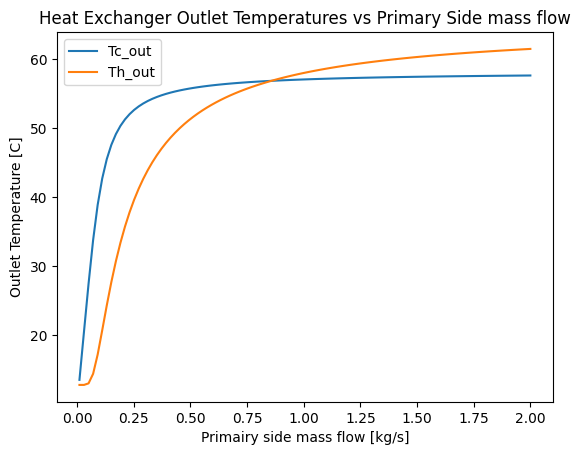

In [54]:
# Determination of Heat Exhanger parameters 
c_water = 4.18e3 
U = 4000  # Overall heat transfer coefficient [W/m2K] obtained via site https://www.engineeringtoolbox.com/heat-transfer-coefficients-exchangers-d_450.html

# Qdot = U * As * F * delta_T_mean
# For tapwater heater
Th_in = 65
Th_out = 35
Tc_in = 10
Tc_out = 60
Qdot = 31e3 # W
F = 0.95

dTmean = (Th_in - Tc_out) - (Th_out - Tc_in) / \
            np.log((Th_in - Tc_out)/(Th_out - Tc_in))

UAs = Qdot / (dTmean * F)
print(f'Tapwater: UAs = {UAs} W/K, U = 4000 W/m2K => As = {UAs/4000} m2')

# For spaceheating, but here you assume the same power as over the tap water HEX
Th_in = 65
Th_out = 35
Tc_in = 30
Tc_out = 60
F = 0.95

delta1 = Th_in - Tc_out
delta2 = Th_out - Tc_in

if delta1 == delta2: 
    dTmean = delta1
else:
    dTmean = (delta1 - delta2) / \
                np.log(delta1/delta2)

Qdot = UAs * (dTmean * F)
print(f'Spaceheating: transferred heat with tapwater parameters {Qdot}')

# Higher UAs needed for tapwater requires less flow for the space heating system. 
# But now the problem is that the 


def NTU_method(mflow_h):
 
    mflow_c = 0.15 # kg/s, max cold side flow rate 

    Th_in = 65
    Tc_in = 10
    F = 0.95

    # Heat capacity rates
    Cc = mflow_c * c_water
    Ch = mflow_h * c_water         

    Cmin = min(Cc, Ch)
    Cmax = max(Cc, Ch)
    Cr = Cmin / Cmax

    NTU = (UAs) / Cmin

    # Effectiveness calculation for counterflow heat exchanger
    if Cr != 1:
        epsilon = (1 - np.exp(-NTU * (1 - Cr))) / (1 - Cr * np.exp(-NTU * (1 - Cr)))
    else:
        epsilon = NTU / (1 + NTU)

    Q = F * epsilon * Cmin * (Th_in - Tc_in)

    Tc_out = Tc_in + Q / Cc
    Th_out = Th_in - Q / Ch
    
    return Tc_out, Th_out

mflowh_in = np.linspace(0.01,2,100)
Tc_out_array = []
Th_out_array = []   
for mflowh in mflowh_in:
    Tc_out, Th_out = NTU_method(mflowh)
    Tc_out_array.append(Tc_out)
    Th_out_array.append(Th_out)

plt.plot(mflowh_in, Tc_out_array, label='Tc_out')
plt.plot(mflowh_in, Th_out_array, label='Th_out')
plt.xlabel('Primairy side mass flow [kg/s]')
plt.ylabel('Outlet Temperature [C]')
plt.title('Heat Exchanger Outlet Temperatures vs Primary Side mass flow')
plt.legend()
plt.show()

# Pressure relation HEX

In [ ]:
# 30 kW = c_p * Qprim * dT_prim_tap, dT_prim_tap = 65 -> 35 degrees
# dp_hex = rho * Kp * mflow ** 2
mflow_prim = 30e3 / (4.18e3 * 30)
dp_hex = 35e3 # Pa according to brochure for primary system
rho = 1000

Kp = 35e3 / (rho * mflow_prim **2)

print(f'Kp {Kp}, mflow {mflow_prim}')

# Pressure pipe with data rutger

In [ ]:
# Determination of the Reynolds number based on the Darcy-Weisbach equation
L  = 3  # m
D = 0.04 # m
v = 0.87 # m/s
dp = 803.5  # Pa

rho = 1000 # kg/m3
epsilon = 0.045e-3 # m

# Re = rho * v * D / mu
mu = 0.001 # Pa.s
Re_check = rho * v * D / mu
f_check = (1 / (-1.8 * np.log10( (epsilon/D)/3.7**1.11 + 6.9/Re_check)))**2
dp = f_check * L * rho * v**2 / (2 * D)
# print(f'f_check = {f_check}, Re check = {Re_check}, dp check = {dp} Pa')

# Solve Haaland equation for Re
f = 2 * dp * D / (L * rho * v**2)
e_term = (epsilon/D/3.7)**1.11
Re = 6.9 / (10**(-1/(1.8*np.sqrt(f))) - e_term)

# print(f' f = {f}, dp = {dp} Pa, Re = {Re}, epsilon/D = {epsilon/D}')

# Equal percentage valve

In [ ]:
# functions return Kv/Kvs

def Kv_book(h, Kv0):
    Kvs = 0.1
    return (Kvs / Kv0) ** (h-1)

def Kv_online(h,n):
    return (np.exp(n*h) - 1) / (np.exp(n)-1)


h = np.linspace(0,1,100)

Kv_book_array = []
Kv_online_array = []
for hi in h:
    Kv_book_array.append(Kv_book(hi,0.1/50))
    Kv_online_array.append(Kv_online(hi,3.2))

# In phd thesis he says that the typical ratio between Kvs/Kv0 is between 25 - 50. Higher ratio means beter control flow. 
# And got from Robbert that the Kvs value is approx 0.1 

plt.figure()
plt.plot(h,Kv_book_array, label = 'book')
plt.plot(h,Kv_online_array, label = 'online')
plt.legend()
plt.xlabel('h (-)')
plt.ylabel('Kv/Kvs (-)')
plt.show()

# Pump 

v_max = 1.5 m/s \
mdot = pi * 0.02 ** 2 * 1.5 * 1000 = 0.6 pi 


[ -4221.7159851  -18568.07669405  50000.        ]


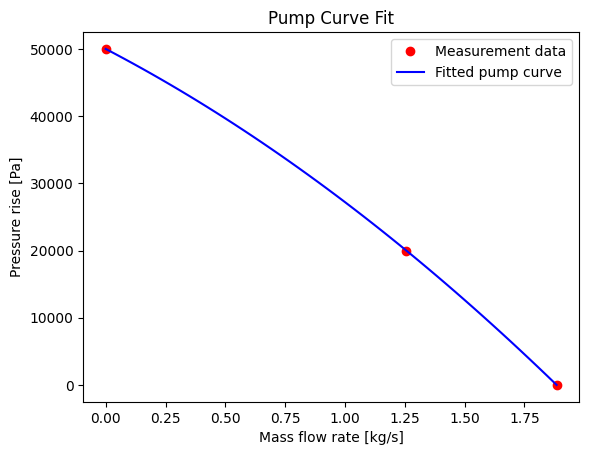

10324.522837926896


In [72]:
# Measurement data points

mflow_max = 0.6 * np.pi  # kg/s
dp_data = np.array([50e3, 20e3, 0])  # Pa
mflow_data = np.array([0, 0.4*np.pi, mflow_max])  # kg/s

# Fit quadratic curve to data: dp = a*mflow^2 + b*mflow + c
coefficients = np.polyfit(mflow_data, dp_data, 2)
a, b, c = coefficients

print(coefficients)

# Update pump_curve function with fitted coefficients
def pump_curve(mflow):
    dp = a * mflow**2 + b * mflow + c
    return dp

# Verify fit
mflow_test = np.linspace(0, mflow_max, 50)
dp_fit = [pump_curve(m) for m in mflow_test]

plt.figure()
plt.plot(mflow_data, dp_data, 'ro', label='Measurement data')
plt.plot(mflow_test, dp_fit, 'b-', label='Fitted pump curve')
plt.xlabel('Mass flow rate [kg/s]')
plt.ylabel('Pressure rise [Pa]')
plt.title('Pump Curve Fit')
plt.legend()
plt.show()

print(pump_curve(1.57369))

# Compare calculated pressure loop with Rutgers data

In [70]:
def dp_tur(L,D,mflow):

    # Re = rho * v * D / mu
    mu = 0.001 # Pa.s for 50 degrees
    epsilon = 0.045e-3
    rho = 1000

    v = mflow / (rho * np.pi * (D/2)**2)
    Re = rho * v * D / mu

    # Re = 10e3

    # print(f'Re {Re}, v {v}')
# 
    log_term = ((epsilon/D)/3.7)**1.11 + (6.9/Re)
    f = (1 / (-1.8 * np.log10(log_term)))**2

    return f * (L / D) * (rho * v**2 / 2)

def dp_lam(L,D,mflow):

    # Re = rho * v * D / mu
    mu = 0.001 # Pa.s for 50 degrees
    rho = 1000

    v = mflow / (rho * np.pi * (D/2)**2)
    Re = rho * v * D / mu

    f = 64/Re
    # print(f)

    return f * (L / D) * (rho * v**2 / 2)

In [71]:
# velocities
vgem1 = 0.8738
vgem2 = 0.8522113
v_hex = vgem1 - vgem2

# Pipe diameters
D = 0.04
D_hex_pipes = 0.02

mflow1 = np.pi * (D/2) **2 * vgem1 * rho
mflow_hex = np.pi * (D/2) ** 2 * v_hex * rho

# Hex pressure calc
Kp = 611
dp_hex = Kp * 1000 * mflow_hex ** 2

dp_meas = 803
m_hex_loop =  dp_tur(3,D_hex_pipes,mflow_hex)
return_pump = dp_tur(3,D,vgem1*np.pi*rho*(D/2)**2)


dp_tot = (dp_hex +  # pressure drop over HEX, where the pipes connected to the nodes are not taken into account
            dp_meas + # measured pressure drop over first pipe of 3 m
            m_hex_loop + # pressure dorp over 3m of DN40 conencted to the HEX loop
            return_pump) # pressure drop over pipe line connected to return network and the pump pipe.

print(f'{dp_tot}: total dp ')
print(f'{dp_hex}: hex dp')
print(f'{m_hex_loop}: 3m hex loop ')
print(f'{return_pump}: 2 m return + pump pipe')
print(f' \n')
print(f'{mflow_hex} mflow_hex ')
print(f'{mflow1} mflow vgem1')

# stel dat de hex flow geleverd is in 1 minuut, terwijl het gemiddlede van een uur is
mflow_hex_1min = mflow_hex*60
Tc_out, Th_out = NTU_method(mflow_hex_1min) # Th_in = 65, Tc_in = 10
print(f'Tc_out = {Tc_out}, Th_out = {Th_out}')

2008.1625996580874: total dp 
449.6907154402365: hex dp
30.72852791082683: 3m hex loop 
724.7433563070239: 2 m return + pump pipe
 

0.027129160528221605 mflow_hex 
1.0980494642827046 mflow vgem1
Tc_out = 57.454884945975756, Th_out = 60.62694863921333


In [77]:
# dp_tur(3,0.04,2.1)

# dp_tur(3,0.04,0.87*np.pi*0.02**2*1000)
50 * 4.18 * 10e3 * 9/60

313500.0